### 📥 Import Required Libraries


In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load the Image



In [44]:
img = cv2.cvtColor(cv2.imread('lowcontrast3.jpg'),cv2.COLOR_BGR2RGB)

## Contrast Enhancement on RGB Color Space


In [45]:
# color image
stretched_channels = []
equ_channels = []
chlahe_channels = []

img_channel = cv2.split(img)

for ch in img_channel:

    ch_min = ch.min()
    ch_max = ch.max()

    ch_stretched = ((ch - ch_min) / (ch_max - ch_min) * 255).astype(np.uint8)
    stretched_channels.append(ch_stretched)


    ch_equ = cv2.equalizeHist(ch)
    equ_channels.append(ch_equ)

    clahe = cv2.createCLAHE(clipLimit=2,tileGridSize=(5,5))
    clahe_ch = clahe.apply(ch)
    chlahe_channels.append(clahe_ch)

img_rgb_stretched = cv2.merge(stretched_channels)
img_rgb_equ = cv2.merge(equ_channels)
img_rgb_clahe = cv2.merge(chlahe_channels)

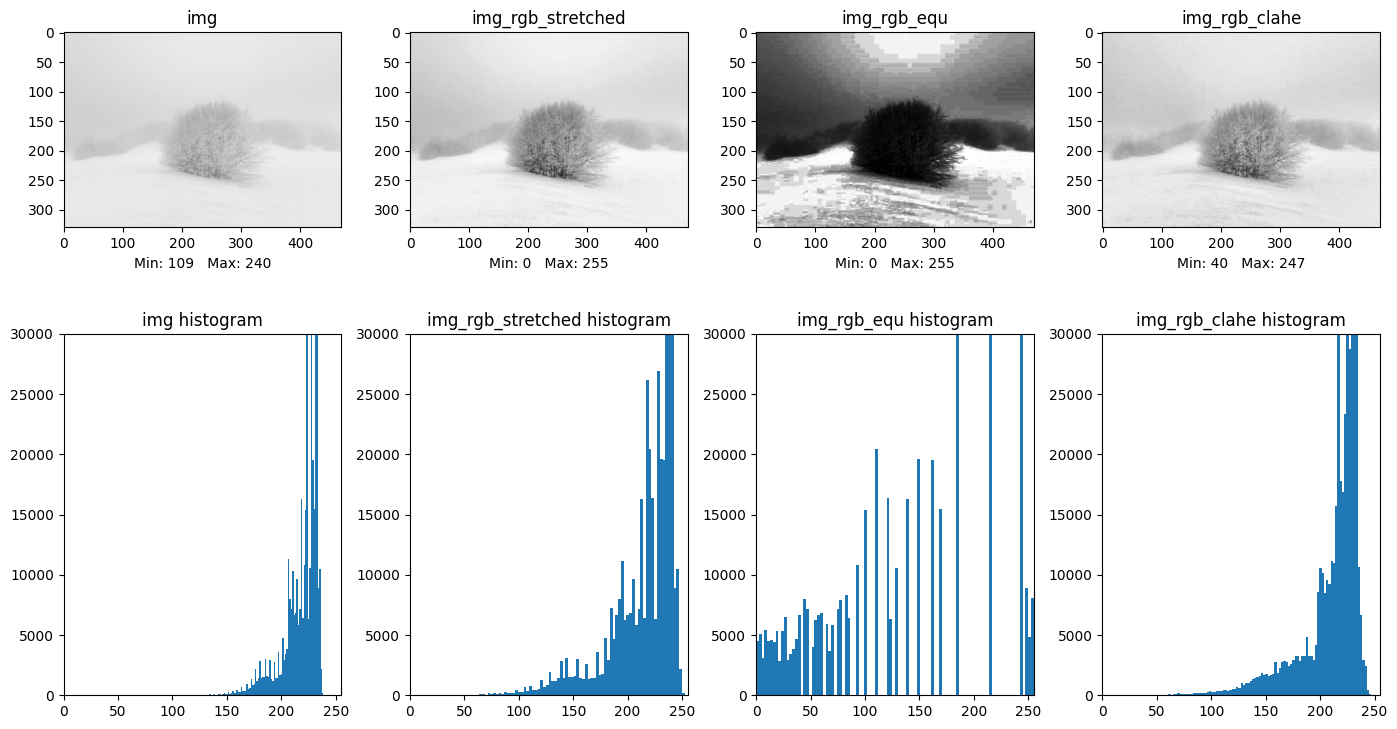

In [46]:

plt.figure(figsize=(14,8))

plt.subplot(2,4,1)
plt.imshow(img)
plt.title("img")
plt.xlabel(f"Min: {img.min()}   Max: {img.max()}")

plt.subplot(2,4,2)
plt.imshow(img_rgb_stretched)
plt.title("img_rgb_stretched")
plt.xlabel(f"Min: {img_rgb_stretched.min()}   Max: {img_rgb_stretched.max()}")

plt.subplot(2,4,3)
plt.imshow(img_rgb_equ, cmap='gray')
plt.title("img_rgb_equ")
plt.xlabel(f"Min: {img_rgb_equ.min()}   Max: {img_rgb_equ.max()}")

plt.subplot(2,4,4)
plt.imshow(img_rgb_clahe, cmap='gray')
plt.title("img_rgb_clahe")
plt.xlabel(f"Min: {img_rgb_clahe.min()}   Max: {img_rgb_clahe.max()}")

plt.subplot(2,4,5)
plt.hist(img.reshape(-1), bins=100)
plt.xlim(0,255)
plt.ylim(0,30000)
plt.title("img histogram")

plt.subplot(2,4,6)
plt.hist(img_rgb_stretched.reshape(-1), bins=100)
plt.xlim(0,255)
plt.ylim(0,30000)
plt.title("img_rgb_stretched histogram")

plt.subplot(2,4,7)
plt.hist(img_rgb_equ.reshape(-1), bins=100)
plt.xlim(0,255)
plt.ylim(0,30000)
plt.title("img_rgb_equ histogram")


plt.subplot(2,4,8)
plt.hist(img_rgb_clahe.reshape(-1), bins=100)
plt.xlim(0,255)
plt.ylim(0,30000)
plt.title("img_rgb_clahe histogram")


plt.tight_layout()
plt.show()

## Contrast Enhancement in HSV Color Space



#### Creating a CLAHE Object in OpenCV

In OpenCV, a CLAHE object can be created using the following function:

```python
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)
```

This function has two important parameters:

### `clipLimit`

This parameter controls the maximum amount of contrast enhancement.

A larger value allows stronger contrast enhancement, while a smaller value limits the amplification of contrast and helps prevent excessive enhancement and noise amplification.

### `tileGridSize`

This parameter specifies the size of the grid used to divide the image into smaller regions (tiles).

For example:

```python
tileGridSize = (8,8)
```

means that the image is divided into an **8 × 8 grid of tiles**, and Histogram Equalization is performed independently on each tile.

By processing local regions instead of the entire image, CLAHE enhances local contrast while preserving the natural appearance of the image.


In [47]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
h,s,v = cv2.split(img_hsv)

v_min = v.min()
v_max = v.max()
print("min v:" , v_min)
print("max v:" , v_max)

v_stretch = (((v - v_min) / (v_max - v_min)) * 255).astype('uint8')

v_stretch_min = v_stretch.min()
v_stretch_max = v_stretch.max()
print("min v_stretch:" , v_stretch_min)
print("max v_stretch:" , v_stretch_max)


img_hsv_stretched = cv2.merge([h,s,v_stretch])

v_equ = cv2.equalizeHist(v)

v_equ_min = v_equ.min()
v_equ_max = v_equ.max()
print("min v_equ:" , v_equ_min)
print("max v_equ:" , v_equ_max)


img_hsv_equ = cv2.merge([h,s,v_equ])


# clahe

clahe = cv2.createCLAHE(clipLimit=2,tileGridSize=(5,5))
v_clahe = clahe.apply(v)
img_hsv_clahe = cv2.merge([h,s,v_clahe])

v_clahe_min = v_clahe.min()
v_clahe_max = v_clahe.max()
print("min v_clahe:" , v_clahe_min)
print("max v_clahe:" , v_clahe_max)

img_hsv_show = cv2.cvtColor(img_hsv,cv2.COLOR_HSV2RGB)
img_hsv_stretched_show = cv2.cvtColor(img_hsv_stretched,cv2.COLOR_HSV2RGB)
img_hsv_equ_show = cv2.cvtColor(img_hsv_equ,cv2.COLOR_HSV2RGB)
img_hsv_clahe_show = cv2.cvtColor(img_hsv_clahe,cv2.COLOR_HSV2RGB)


min v: 109
max v: 240
min v_stretch: 0
max v_stretch: 255
min v_equ: 0
max v_equ: 255
min v_clahe: 40
max v_clahe: 247


As we can see, in both **Histogram Stretching** and **Histogram Equalization**, the intensity range of the V channel has been expanded to the full **0–255** range. These methods are designed to utilize the entire available dynamic range, so the minimum intensity becomes **0** and the maximum becomes **255**.

However, the result of **CLAHE (Contrast Limited Adaptive Histogram Equalization)** is different. The V channel values range from **40** to **247**, meaning that the full **0–255** range is not used.

The reason is that, unlike the previous two methods, CLAHE is a **local enhancement** technique that processes small image regions (tiles) independently. In addition, it uses the **clip limit** parameter to prevent excessive contrast amplification. As a result, pixel intensities are not forced to reach **0** and **255**. Instead, CLAHE enhances local contrast while avoiding over-enhancement, reducing noise amplification, and preserving image details.

Therefore, it is completely expected that the minimum and maximum intensity values after applying CLAHE are **40** and **247**, rather than **0** and **255**. This behavior is one of the key characteristics of CLAHE, demonstrating that its objective is not to stretch the histogram across the entire intensity range, but to improve local contrast in a controlled manner while maintaining a more natural appearance.


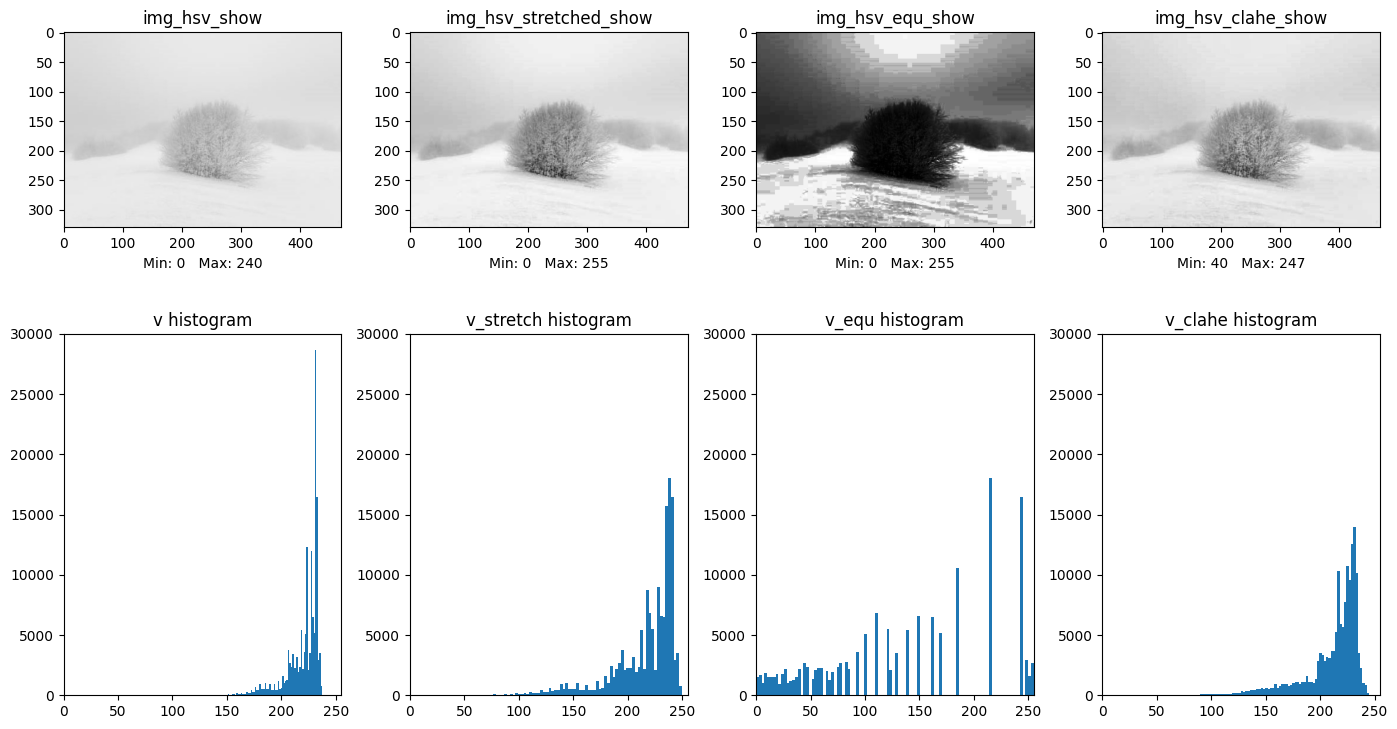

In [48]:

img_gray_eq = cv2.equalizeHist(img_gray)

plt.figure(figsize=(14,8))

plt.subplot(2,4,1)
plt.imshow(img_hsv_show)
plt.title("img_hsv_show")
plt.xlabel(f"Min: {img_hsv.min()}   Max: {img_hsv.max()}")

plt.subplot(2,4,2)
plt.imshow(img_hsv_stretched_show)
plt.title("img_hsv_stretched_show")
plt.xlabel(f"Min: {v_stretch.min()}   Max: {v_stretch.max()}")

plt.subplot(2,4,3)
plt.imshow(img_hsv_equ_show, cmap='gray')
plt.title("img_hsv_equ_show")
plt.xlabel(f"Min: {v_equ.min()}   Max: {v_equ.max()}")

plt.subplot(2,4,4)
plt.imshow(img_hsv_clahe_show, cmap='gray')
plt.title("img_hsv_clahe_show")
plt.xlabel(f"Min: {v_clahe.min()}   Max: {v_clahe.max()}")

plt.subplot(2,4,5)
plt.hist(v.reshape(-1), bins=100)
plt.xlim(0,255)
plt.ylim(0,30000)
plt.title("v histogram")

plt.subplot(2,4,6)
plt.hist(v_stretch.reshape(-1), bins=100)
plt.xlim(0,255)
plt.ylim(0,30000)
plt.title("v_stretch histogram")

plt.subplot(2,4,7)
plt.hist(v_equ.reshape(-1), bins=100)
plt.xlim(0,255)
plt.ylim(0,30000)
plt.title("v_equ histogram")


plt.subplot(2,4,8)
plt.hist(v_clahe.reshape(-1), bins=100)
plt.xlim(0,255)
plt.ylim(0,30000)
plt.title("v_clahe histogram")


plt.tight_layout()
plt.show()

Another important observation can be made from the histogram. In the original **V** channel, some intensity values have frequencies close to **30,000** pixels, indicating that a large number of pixels are concentrated within a narrow intensity range.

After applying **CLAHE**, the maximum frequency decreases to approximately **14,000** pixels. This indicates that the pixel intensities have been redistributed more evenly across neighboring intensity levels, reducing the concentration of pixels at a few dominant values and improving local contrast.

It can also be observed that the histogram shifts slightly toward darker intensity values. However, unlike Histogram Stretching or Histogram Equalization, the distribution is **not** expanded all the way to **0**. This is expected because CLAHE performs **local** histogram equalization with **contrast limiting**, rather than forcing the intensity values to span the entire dynamic range. As a result, the histogram becomes more balanced while avoiding excessive contrast enhancement and preserving the natural appearance of the image.
